# 05 - Feature Relevance Audit

Uses the best tree-based model from notebook 04 to compute permutation importance, then saves only the features that contribute meaningfully to `debug_exports/top_features.json`.

2026-05-31 16:37:22.818694: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 16:37:22.823620: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 16:37:22.839204: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780227442.863375  120801 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780227442.870350  120801 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780227442.887641  120801 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

,expected_weather_fields,present_weather_fields,missing_weather_fields,expected_air_fields,present_air_fields,missing_air_fields,selected_features
0,30,28,2,23,21,2,40


,feature,permutation_importance,share,cumulative_share
0,wind_speed_10m_rolling_std_168h,0.553364,0.175899,0.175899
1,hour_sin,0.370433,0.117750,0.293649
2,is_day,0.313359,0.099608,0.393258
3,hour_of_day,0.249196,0.079212,0.472470
4,solar_radiation_category,0.222285,0.070658,0.543128
5,european_aqi_rolling_std_168h,0.194752,0.061906,0.605034
6,day_of_week_cos,0.110715,0.035193,0.640228
7,hour_cos,0.097644,0.031038,0.671266
8,european_aqi_rolling_std_24h,0.090496,0.028766,0.700032
9,european_aqi_rolling_min_168h,0.058704,0.018660,0.718693


Saved /home/mwasifshakeel/Videos/pearls-aqi-predictor/debug_exports/top_features.json
Selected 40 features from extra_trees on the 80-day window


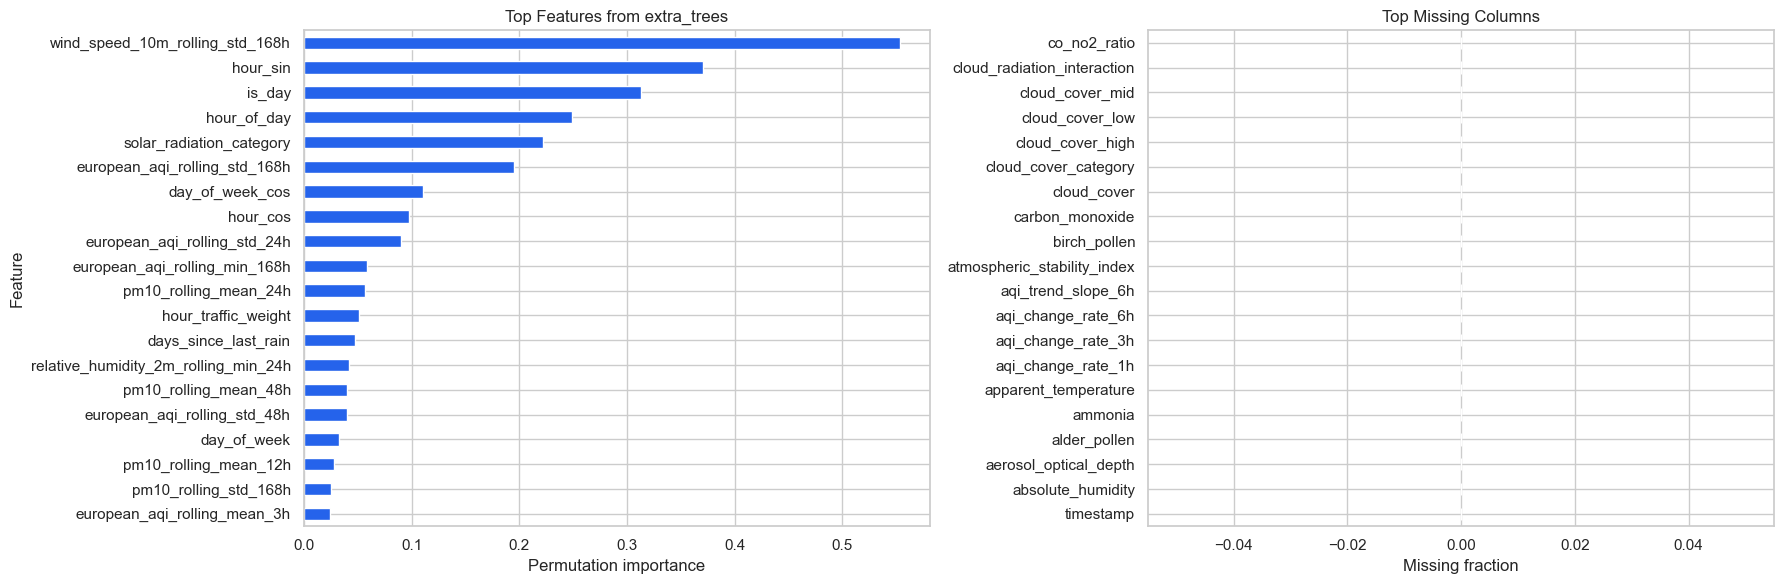

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from dotenv import load_dotenv
from IPython.display import display
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, mean_squared_error

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
load_dotenv(str(ROOT / ".env"), override=False)

from src.data.fetch_openmeteo import AIR_QUALITY_HOURLY, WEATHER_HOURLY
from src.features.feature_catalog import get_feature_catalog
from src.models.model_configs import MODEL_CONFIGS
from src.models.train import train_model
from src.utils.mongo_client import get_database

sns.set_theme(style="whitegrid")

ARTIFACTS_DIR = ROOT / "debug_exports"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
TREE_MODEL_NAMES = {"lightgbm", "xgboost", "catboost", "random_forest", "extra_trees", "gradient_boosting"}

HORIZON = 72
SPLIT_RATIO = 0.9


def load_json(path: Path, default):
    if not path.exists():
        return default
    try:
        with open(path, "r", encoding="utf-8") as handle:
            return json.load(handle)
    except (OSError, json.JSONDecodeError):
        return default


def load_text(path: Path, default: str | None = None) -> str | None:
    if not path.exists():
        return default
    try:
        value = path.read_text(encoding="utf-8").strip()
        return value or default
    except OSError:
        return default


db = get_database()
collection = db["aqi_features_rawalpindi"]
data = pd.DataFrame(list(collection.find()))

if data.empty:
    raise ValueError("aqi_features_rawalpindi is empty")

if "_id" in data.columns:
    data = data.drop(columns=["_id"])

data["timestamp"] = pd.to_datetime(data["timestamp"], utc=True, errors="coerce")
data = data.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

feature_cols = [column for column in get_feature_catalog() if column in data.columns]
# Default window for feature importance (days)
best_window_days = 80
# If you'd like to use a previously saved best window, set use_saved_window = True
use_saved_window = False
if use_saved_window:
    window_payload = load_json(ARTIFACTS_DIR / "best_window_days.json", {})
    if isinstance(window_payload, dict):
        best_window_days = int(window_payload.get("best_window_days", best_window_days))
# Choose a tree model to compute permutation importance. Default to lightgbm if none saved.
best_tree_model_name = load_text(ARTIFACTS_DIR / "best_tree_model_name.txt") or load_text(ARTIFACTS_DIR / "best_model_name.txt")
if not best_tree_model_name:
    best_tree_model_name = "lightgbm"
if best_tree_model_name not in TREE_MODEL_NAMES:
    best_tree_model_name = "lightgbm"

window_start = data["timestamp"].max() - pd.Timedelta(days=best_window_days)
window_frame = data.loc[data["timestamp"] >= window_start].sort_values("timestamp").reset_index(drop=True)

if len(window_frame) <= HORIZON:
    raise ValueError("Not enough rows in the selected window to compute feature importance")

split_index = int(len(window_frame) * SPLIT_RATIO)
if split_index <= HORIZON:
    raise ValueError("Not enough rows to create a leakage-safe split")


def prepare_training_matrices(feature_frame: pd.DataFrame, target: pd.Series, split_index: int):
    if feature_frame.empty or len(feature_frame) <= HORIZON:
        return None, None, None, None, None

    max_start = len(target) - HORIZON
    if max_start <= 0 or split_index <= HORIZON or split_index >= max_start:
        return None, None, None, None, None

    x = feature_frame.iloc[:max_start].copy()
    y = pd.DataFrame([target.iloc[i : i + HORIZON].values for i in range(max_start)], index=x.index)
    start_indices = np.arange(max_start)

    train_mask = start_indices + HORIZON <= split_index
    val_mask = start_indices >= split_index

    if not train_mask.any() or not val_mask.any():
        return None, None, None, None, None

    return x.iloc[train_mask], y.iloc[train_mask], x.iloc[val_mask], y.iloc[val_mask], list(x.columns)


target = window_frame["european_aqi"].astype(float)
feature_frame = window_frame[feature_cols].apply(pd.to_numeric, errors="coerce")
feature_frame = feature_frame.replace([np.inf, -np.inf], np.nan).ffill().fillna(0.0)
feature_frame = feature_frame.loc[:, feature_frame.nunique(dropna=True) > 1].copy()

x_train, y_train, x_val, y_val, used_features = prepare_training_matrices(feature_frame, target, split_index)
if x_train is None or y_train is None or x_val is None or y_val is None:
    raise ValueError("Unable to prepare training matrices for feature importance")

model_config = next((config for config in MODEL_CONFIGS if config.name == best_tree_model_name), None)
if model_config is None:
    raise ValueError(f"Model config not found for {best_tree_model_name}")

model, _, _ = train_model(model_config, x_train, y_train, horizon=HORIZON)
if x_val.empty or y_val.empty:
    raise ValueError("Validation slice is empty for feature importance")

# Use RMSE scorer wrapper to avoid incompatible sklearn parameter passing
import numpy as _np
from sklearn.metrics import mean_squared_error as _mse

def _rmse(y_true, y_pred):
    return float(_np.sqrt(_mse(y_true, y_pred)))

scorer = make_scorer(_rmse, greater_is_better=False)
importance_result = permutation_importance(model, x_val, y_val, n_repeats=5, random_state=42, scoring=scorer)
importance_df = pd.DataFrame(
    {
        "feature": x_val.columns,
        "importance": importance_result.importances_mean,
    }
)
importance_df["importance"] = importance_df["importance"].clip(lower=0.0)
importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

if importance_df["importance"].sum() > 0:
    importance_df["share"] = importance_df["importance"] / importance_df["importance"].sum()
else:
    importance_df["share"] = 0.0
importance_df["cumulative_share"] = importance_df["share"].cumsum()

selected_features = importance_df.loc[importance_df["cumulative_share"] <= 0.95, "feature"].tolist()
if len(selected_features) < 12:
    selected_features = importance_df.head(min(20, len(importance_df)))["feature"].tolist()
selected_features = selected_features[:40]

top_features_payload = {
    "features": selected_features,
    "model_name": best_tree_model_name,
    "best_window_days": best_window_days,
    "feature_count": len(selected_features),
    "selection_rule": "permutation_importance_cumulative_share_0.95",
    "top_importances": importance_df.head(25).to_dict(orient="records"),
}
with open(ARTIFACTS_DIR / "top_features.json", "w", encoding="utf-8") as handle:
    json.dump(top_features_payload, handle, indent=2)

importance_df.to_csv(ARTIFACTS_DIR / "feature_importance_metrics.csv", index=False)

audit = pd.DataFrame(
    {
        "expected_weather_fields": [len(WEATHER_HOURLLY)] if 'WEATHER_HOURLLY' in globals() else [len(WEATHER_HOURLY)],
        "present_weather_fields": [len(set(WEATHER_HOURLY) & set(data.columns))],
        "missing_weather_fields": [len(set(WEATHER_HOURLY) - set(data.columns))],
        "expected_air_fields": [len(AIR_QUALITY_HOURLY)],
        "present_air_fields": [len(set(AIR_QUALITY_HOURLY) & set(data.columns))],
        "missing_air_fields": [len(set(AIR_QUALITY_HOURLY) - set(data.columns))],
        "selected_features": [len(selected_features)],
    }
)

display(audit)
display(importance_df.head(25).rename(columns={"importance": "permutation_importance"}))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
importance_df.head(20).sort_values("importance").plot(kind="barh", x="feature", y="importance", ax=axes[0], color="#2563eb", legend=False)
axes[0].set_title(f"Top Features from {best_tree_model_name}")
axes[0].set_xlabel("Permutation importance")
axes[0].set_ylabel("Feature")

missingness = data.isna().mean().sort_values(ascending=False).head(20)
missingness.plot(kind="barh", ax=axes[1], color="#dc2626")
axes[1].set_title("Top Missing Columns")
axes[1].set_xlabel("Missing fraction")

plt.tight_layout()

print(f"Saved {ARTIFACTS_DIR / 'top_features.json'}")
print(f"Selected {len(selected_features)} features from {best_tree_model_name} on the {best_window_days}-day window")